# Notebook 06 - Final Evaluation & Cross-Model Comparision

This notebook consolidates results from all baseline and transformer models into a unified evaluation framework. It aggregates metrics into structured tables and performs detailed comparative analysis.

Key components include:
- ROC and Precision-Recall curve visualisation
- Metric comparison across models
- Confusion matrix analysis for error interpretation
- Error breakdown (false positives vs false negatives)
- Statistical significance testing using McNemar’s test
- Threshold optimisation to balance precision-recall trade-offs
- Calibration analysis using reliability diagrams and Brier scores

The notebook provides a rigorous, multi-dimensional evaluation of model performance and identifies the best model based on quantitative and statistical evidence.

## Evaluation Setup and Environment Configuration

This section initialises the environment required for comparative evaluation of all models. It includes the necessary library imports, configuration parameters, and file paths used throughout the evaluation stage.

Core libraries for data handling, visualisation, and statistical analysis are loaded to support performance comparison and result interpretation. In addition, precomputed model outputs and metrics are accessed through stored files, ensuring that evaluation is reproducible and independent of the training phase.

Custom plotting configurations and consistent visual styles are defined to maintain uniformity across all figures. Distinct colour mappings and line styles are assigned to each model, allowing clear differentiation between baseline and transformer-based approaches.

An output directory is also created to store evaluation results and visualisations. This structured setup ensures that all comparative analyses are organised, reproducible, and aligned with the overall experimental pipeline.

In [1]:
# Add project root directory to system path for module imports
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Core libraries for data handling and computation
import pandas as pd
import numpy as np

# Visualization library
import matplotlib.pyplot as plt

# For loading saved model predictions and objects
import pickle

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Statistical function for significance testing
from scipy.stats import chi2 as chi2_dist

# Evaluation metrics for model performance
from sklearn.metrics import (
    roc_curve, precision_recall_curve,
    roc_auc_score, average_precision_score,
    brier_score_loss,f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)

# Calibration Tools
from sklearn.calibration import calibration_curve

# File Paths and Configuration Constants
from config import (
    BASELINE_RESULTS_CSV,
    DISTILBERT_RESULTS_CSV, PUBMEDBERT_RESULTS_CSV, BIOBERT_RESULTS_CSV,
    DISTILBERT_PREDS_PKL, PUBMEDBERT_PREDS_PKL, BIOBERT_PREDS_PKL,
    BEST_BASELINE_PKL, ALL_RESULTS_CSV,
    PLOTS_DIR, METRICS_DIR,
)

# Evaluation Results Output Directory Setup
EVALUATION_DIR = PLOTS_DIR / "evaluation_results"
EVALUATION_DIR.mkdir(parents=True, exist_ok=True)

# Global Plotting Styles
plt.rcParams.update({
    'figure.dpi':120,
    'axes.spines.top':False,
    'axes.spines.right':False,
    'font.size':11,
})

# Color Coding for Models
MODEL_COLORS = {
    'Logistic Regression':'#A8C8E1',
    'Random Forest':'#F4B9BE',
    'Linear SVM':'#B5D5C5',
    'DistilBERT':'#2E86AB',
    'PubMedBERT':'#E84855',
    'BioBERT':'#2A9D8F',
}

# Line Styles
MODEL_LS = {
    'Logistic Regression':'--',
    'Random Forest':'--',
    'Linear SVM':'--',
    'DistilBERT':'-',
    'PubMedBERT':'-',
    'BioBERT':'-',
}

# Color Palette
PALETTE = ['#2E86AB','#E84855','#F4A261','#2A9D8F','#8338EC']

## Aggregation of Model Results and Prediction Outputs

This section consolidates the evaluation results from all baseline and transformer models into a unified structure for comparative analysis. Combining results ensures that all models can be assessed consistently using the same evaluation framework.

Performance metrics from individual result files are merged into a single dataframe and stored for downstream comparison. This enables direct evaluation of model performance across different architectures and training strategies.

Prediction outputs for each model are then loaded from saved artifacts. These include predicted labels, probabilities, and associated evaluation components, which are required for further analysis such as curve plotting and statistical testing.

The test set labels are extracted and verified to be consistent across all models. Summary statistics of the test set are also displayed to provide context for interpreting model performance, particularly with respect to class distribution.

In [2]:
# Combine results from baseline and transformer models
all_results = pd.concat([
    pd.read_csv(BASELINE_RESULTS_CSV),
    pd.read_csv(DISTILBERT_RESULTS_CSV),
    pd.read_csv(PUBMEDBERT_RESULTS_CSV),
    pd.read_csv(BIOBERT_RESULTS_CSV),
], ignore_index=True)

# Save combined results
all_results.to_csv(ALL_RESULTS_CSV, index=False)

# Display number of models loaded
print(f'Models loaded: {len(all_results)}')

# Utility function to load pickle files
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

# Load prediction outputs for each model
db_preds = load_pkl(DISTILBERT_PREDS_PKL)
pm_preds = load_pkl(PUBMEDBERT_PREDS_PKL)
bb_preds = load_pkl(BIOBERT_PREDS_PKL)
bl_preds = load_pkl(BEST_BASELINE_PKL)

# Extract test labels (same across all models)
y_test = db_preds['y_test']

# Display test set statistics
print(f'Test set: {len(y_test):,}  |  '
      f'Positive: {y_test.sum()} ({y_test.mean()*100:.1f}%)')

Models loaded: 6
Test set: 3,610  |  Positive: 694 (19.2%)


## Summary of Model Performance Metrics

This section presents a consolidated summary of performance metrics for all evaluated models in a structured tabular format. Bringing together results from both baseline and transformer models enables direct and consistent comparison.

The table includes key evaluation metrics such as accuracy, weighted F1-score, precision, recall, ROC-AUC, and PR-AUC. These metrics collectively capture both overall classification performance and the model’s effectiveness on the positive class under imbalance.

Results are formatted with consistent precision to improve readability and ensure clarity when interpreting differences across models. This standardised presentation also supports seamless integration into the final report.

By providing a unified view of model performance, this section forms the basis for comparative analysis and selection of the most effective modelling approach.

In [3]:
# Columns for reporting
cols = [
    'Model','Type','Accuracy','F1_Weighted',
    'Precision_Pos','Recall_Pos','F1_Pos','ROC_AUC','PR_AUC'
]

# Print formatted results table
print('\n' + '='*90)
print('  RESULTS TABLE  ')
print('='*90)

table = all_results[cols].to_string(
    index=False,
    float_format='{:.4f}'.format
)

print(table)

print('='*90)


  RESULTS TABLE  
              Model        Type  Accuracy  F1_Weighted  Precision_Pos  Recall_Pos  F1_Pos  ROC_AUC  PR_AUC
Logistic Regression    Baseline    0.6939       0.7199         0.3272      0.5605  0.4132   0.7021  0.3882
      Random Forest    Baseline    0.7008       0.7208         0.3126      0.4640  0.3735   0.6776  0.3744
         Linear SVM    Baseline    0.8108       0.7344         0.6667      0.0317  0.0605   0.6912  0.3666
         DistilBERT Transformer    0.6657       0.6983         0.3115      0.6110  0.4127   0.7041  0.4051
         PubMedBERT Transformer    0.6825       0.7111         0.3183      0.5706  0.4087   0.7080  0.4066
            BioBERT Transformer    0.6723       0.7034         0.3138      0.5937  0.4106   0.7025  0.3996


## Comparative Performance Curves Across Models

This section presents a comparative analysis of all models using ROC and Precision–Recall curves. Visualising performance curves enables a comprehensive comparison of model behaviour across different decision thresholds.

Both baseline and transformer models are included to provide a unified evaluation framework. The baseline model is plotted using dashed lines, while transformer models are represented with solid lines for clear differentiation.

ROC curves illustrate the trade-off between true positive rate and false positive rate, providing insight into overall discriminative ability. Precision–Recall curves focus on performance for the positive class and are particularly informative in the presence of class imbalance.

By analysing these curves together, it becomes possible to identify the relative strengths of each model and assess whether transformer-based approaches provide meaningful improvements over traditional baselines.

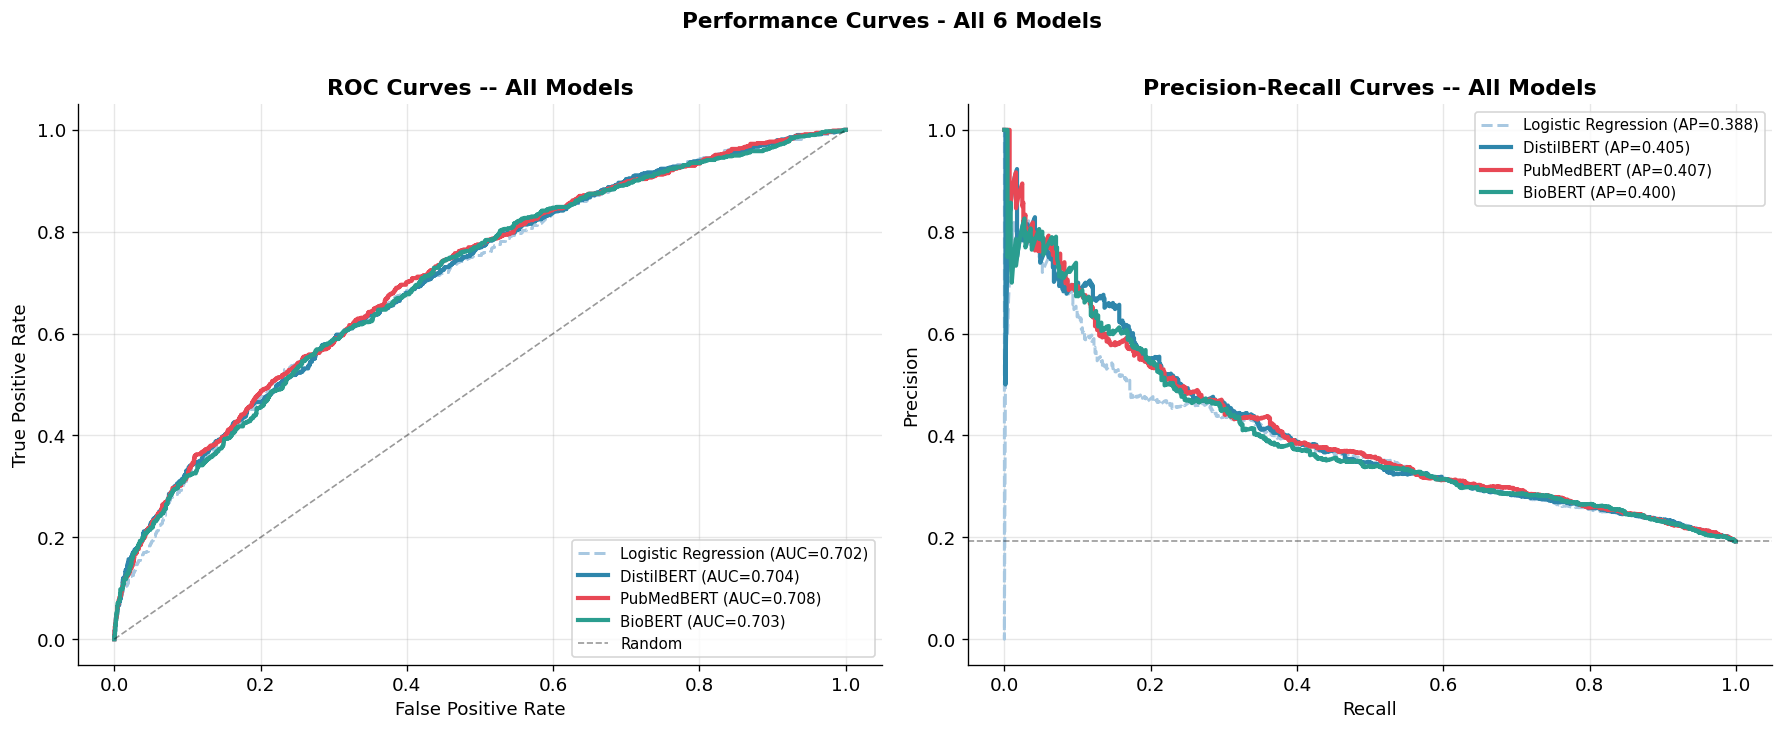

In [4]:
# Setup: model groups
TRANSFORMER_PREDS = [
    ('DistilBERT', db_preds),
    ('PubMedBERT', pm_preds),
    ('BioBERT', bb_preds),
]

# Figure initialisation
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Baseline model metrics
bl_name = bl_preds['name']
bl_probs = bl_preds['y_prob']

bl_fpr, bl_tpr, _ = roc_curve(y_test, bl_probs)
bl_prec, bl_rec, _ = precision_recall_curve(y_test, bl_probs)

bl_roc = roc_auc_score(y_test, bl_probs)
bl_pr = average_precision_score(y_test, bl_probs)

# Plot baseline
axes[0].plot(
    bl_fpr, bl_tpr,
    color=MODEL_COLORS.get(bl_name,'grey'),
    ls='--', lw=1.8,
    label=f'{bl_name} (AUC={bl_roc:.3f})'
)

axes[1].plot(
    bl_rec, bl_prec,
    color=MODEL_COLORS.get(bl_name,'grey'),
    ls='--', lw=1.8,
    label=f'{bl_name} (AP={bl_pr:.3f})'
)

# Transformer models
for name, preds in TRANSFORMER_PREDS:
    probs = preds['y_prob']

    fpr, tpr, _ = roc_curve(y_test, probs)
    prec, rec, _ = precision_recall_curve(y_test, probs)

    axes[0].plot(
        fpr, tpr,
        color=MODEL_COLORS[name],
        ls='-', lw=2.5,
        label=f'{name} (AUC={preds["roc_auc"]:.3f})'
    )

    axes[1].plot(
        rec, prec,
        color=MODEL_COLORS[name],
        ls='-', lw=2.5,
        label=f'{name} (AP={preds["pr_auc"]:.3f})'
    )

# Plot formatting
axes[0].plot([0,1],[0,1],'k--', lw=1, alpha=0.4, label='Random')
axes[0].set_title('ROC Curves -- All Models', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9, loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1, alpha=0.4)
axes[1].set_title('Precision-Recall Curves -- All Models', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9, loc='upper right')
axes[1].grid(True, alpha=0.3)

# Save and display
plt.suptitle(
    'Performance Curves - All 6 Models',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()

plt.savefig(
    f'{EVALUATION_DIR}/eval_01_combined_roc_pr.png',
    dpi=150, bbox_inches='tight'
)

plt.show()

## Comparative Analysis of Key Performance Metrics

This section compares all models across selected evaluation metrics using a grouped bar chart. Visual comparison of key metrics enables a clearer understanding of relative model performance on the test set.

The analysis focuses on weighted F1-score, ROC-AUC, PR-AUC, and recall for the positive class. These metrics capture both overall classification quality and the model’s ability to correctly identify readmission cases.

Models are organised into two groups: baseline models and transformer-based models. A visual separation is introduced to highlight differences in performance between traditional machine learning approaches and deep learning models.

By presenting multiple metrics simultaneously, this comparison provides a balanced view of model strengths and trade-offs, supporting informed selection of the most effective approach.

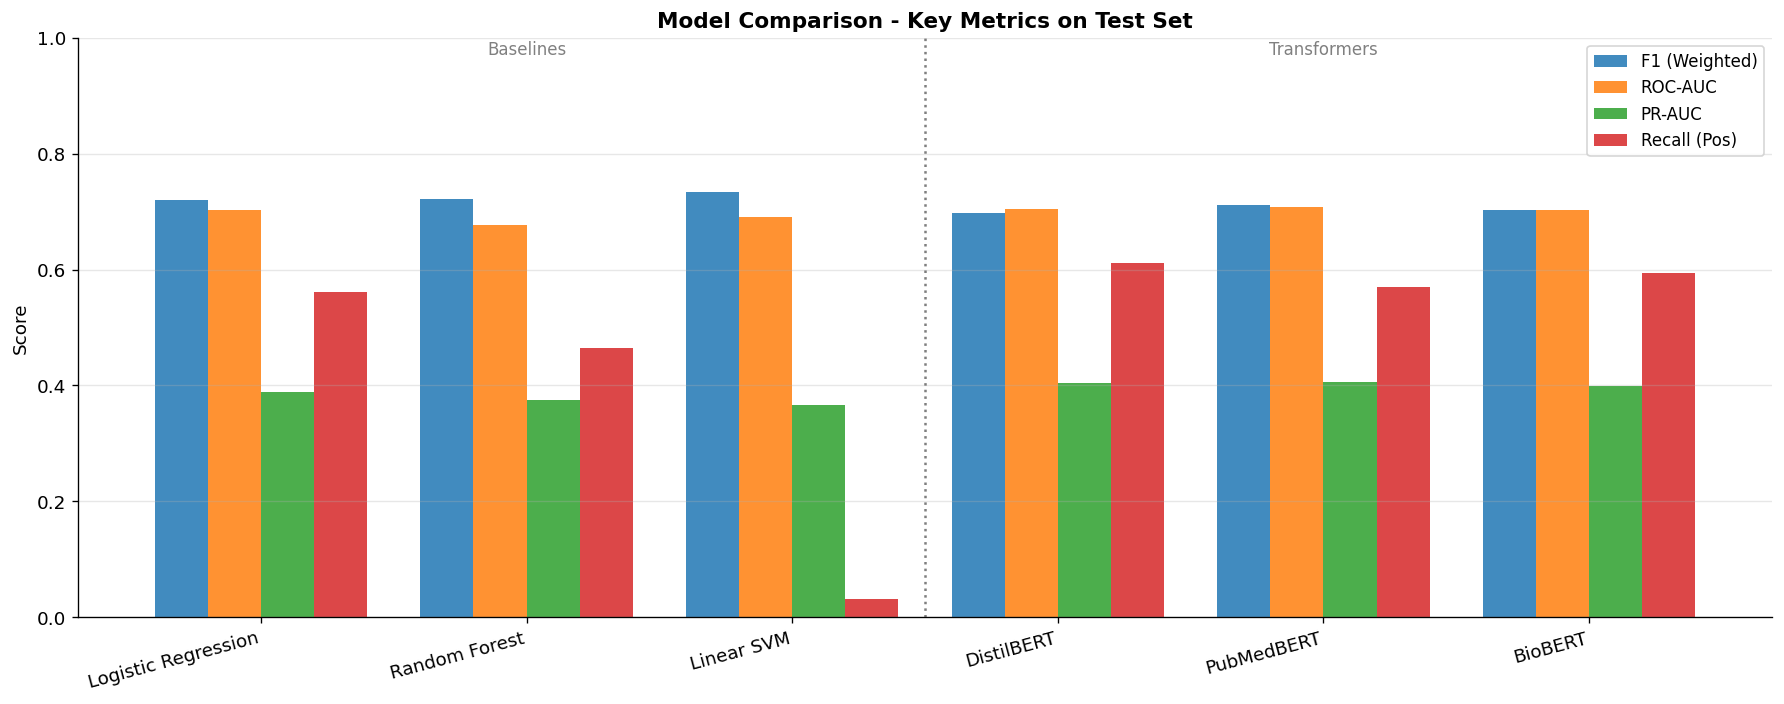

In [5]:
# Metrics and labels
metrics_show = ['F1_Weighted','ROC_AUC','PR_AUC','Recall_Pos']
metric_labels = ['F1 (Weighted)','ROC-AUC','PR-AUC','Recall (Pos)']

# Model order for consistent plotting
model_order = [
    'Logistic Regression','Random Forest','Linear SVM',
    'DistilBERT','PubMedBERT','BioBERT'
]

# X-axis setup
x = np.arange(len(model_order))
width = 0.2

# Create figure
fig, ax = plt.subplots(figsize=(15, 6))


# Extract and plot metrics
for i, (metric, label) in enumerate(zip(metrics_show, metric_labels)):
    vals = []

    for m in model_order:
        row = all_results[all_results['Model'] == m]
        vals.append(float(row[metric].values[0]) if len(row) else 0)

    ax.bar(
        x + (i - 1.5) * width,
        vals,
        width,
        label=label,
        alpha=0.85
    )

# Visual separation between model groups
ax.axvline(x=2.5, color='black', linestyle=':', lw=1.5, alpha=0.5)

ax.text(
    1.0, 0.97, 'Baselines',
    ha='center', fontsize=10,
    color='grey',
    transform=ax.get_xaxis_transform()
)

ax.text(
    4.0, 0.97, 'Transformers',
    ha='center', fontsize=10,
    color='grey',
    transform=ax.get_xaxis_transform()
)

# Axis formatting
ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=15, ha='right')

ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')

ax.set_title(
    'Model Comparison - Key Metrics on Test Set',
    fontweight='bold', fontsize=13
)

ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

# Save and display
plt.tight_layout()

plt.savefig(
    f'{EVALUATION_DIR}/eval_02_model_comparison_bars.png',
    dpi=150, bbox_inches='tight'
)

plt.show()

## Confusion Matrix Analysis for Transformer Models

This section presents confusion matrices for all transformer-based models on the test set. Confusion matrices provide a detailed breakdown of prediction outcomes, allowing direct inspection of classification errors.

Each matrix displays the number of true positives, true negatives, false positives, and false negatives. This enables a more granular understanding of model behaviour beyond aggregate performance metrics.

Sensitivity (recall for the positive class) and specificity (true negative rate) are also computed and reported for each model. These measures are particularly important in evaluating performance in a clinical context, where correctly identifying positive cases and avoiding false alarms are both critical.

By comparing confusion matrices across transformer models, this section highlights differences in error distribution and supports deeper interpretation of their predictive performance.

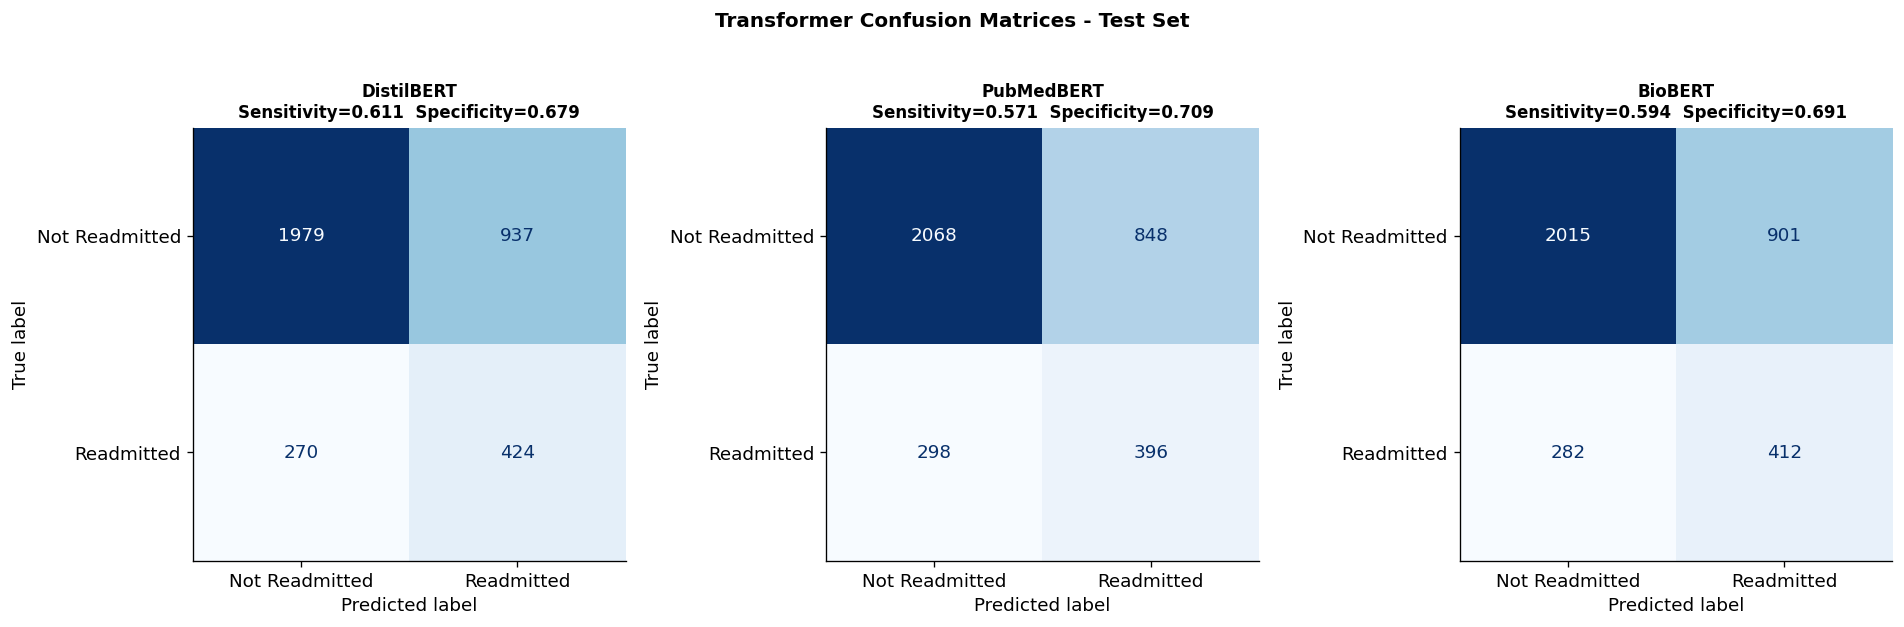

In [6]:
# Create subplots for confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot confusion matrices for transformer models
for ax, (name, preds) in zip(axes, TRANSFORMER_PREDS):
    cm = confusion_matrix(y_test, preds['y_pred'])

    tn, fp, fn, tp = cm.ravel()

    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    ConfusionMatrixDisplay(
        cm,
        display_labels=['Not Readmitted','Readmitted']
    ).plot(
        ax=ax,
        colorbar=False,
        cmap='Blues'
    )

    ax.set_title(
        f'{name}\nSensitivity={sens:.3f}  Specificity={spec:.3f}',
        fontweight='bold',
        fontsize=10
    )

# Save and display
plt.suptitle(
    'Transformer Confusion Matrices - Test Set',
    fontsize=12,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()

plt.savefig(
    f'{EVALUATION_DIR}/eval_03_transformer_confusion_matrices.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Error Distribution Analysis for Transformer Models

This section analyses the distribution of prediction errors for transformer-based models using a detailed breakdown of confusion matrix components. Understanding error types is essential for evaluating model behaviour in practical settings.

For each model, counts of true positives, false positives, true negatives, and false negatives are visualised. This provides a clear representation of how predictions are distributed across correct and incorrect outcomes.

Particular attention is given to false positives and false negatives, as these error types have different implications in a clinical context. False negatives correspond to missed readmissions, while false positives represent unnecessary alerts.

By comparing error distributions across models, this analysis highlights trade-offs in prediction behaviour and supports more informed interpretation of model performance beyond aggregate metrics.

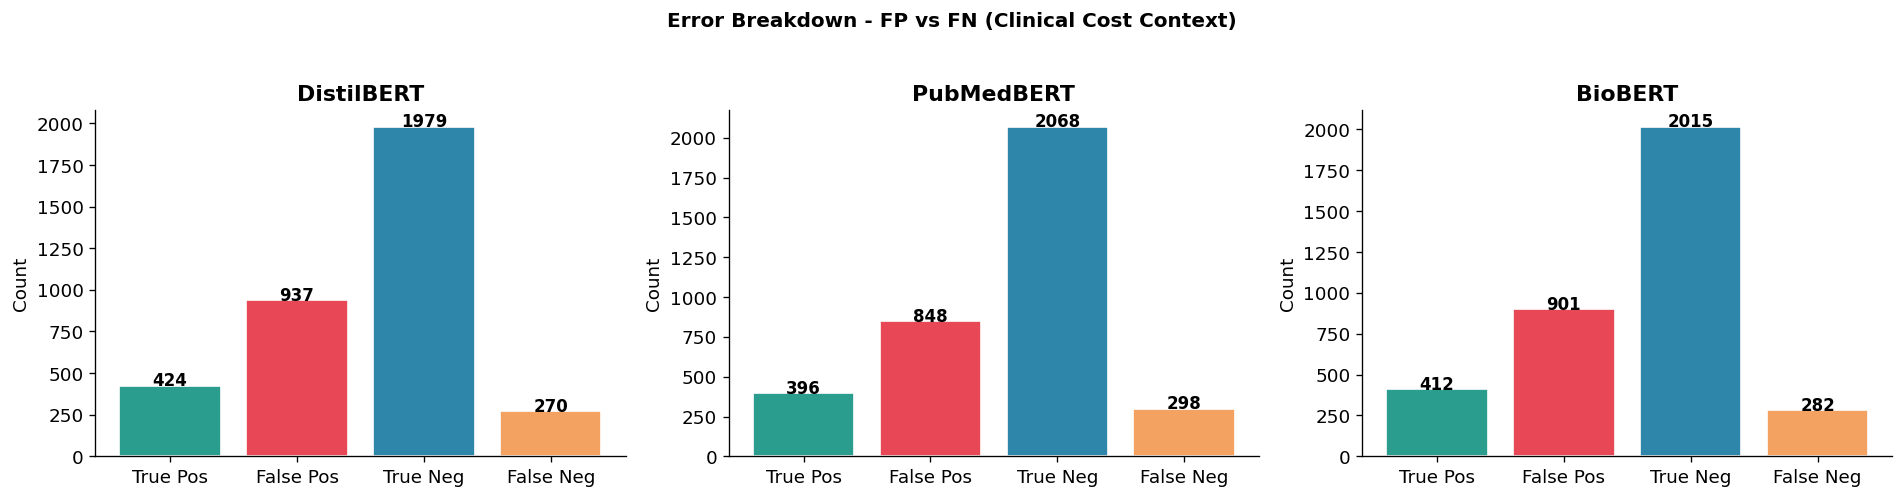

In [7]:
# Create subplots for error analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Define colors for error categories
error_colors = ['#2A9D8F','#E84855','#2E86AB','#F4A261']

# Plot error breakdown for each transformer model
for ax, (name, preds) in zip(axes, TRANSFORMER_PREDS):
    cm = confusion_matrix(y_test, preds['y_pred'])

    tn, fp, fn, tp = cm.ravel()

    vals = [tp, fp, tn, fn]
    labels = ['True Pos','False Pos','True Neg','False Neg']

    bars = ax.bar(
        labels,
        vals,
        color=error_colors,
        edgecolor='white'
    )

    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            str(v),
            ha='center',
            fontweight='bold',
            fontsize=10
        )

    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Count')

# Save and display
plt.suptitle(
    'Error Breakdown - FP vs FN (Clinical Cost Context)',
    fontsize=12,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()

plt.savefig(
    f'{EVALUATION_DIR}/eval_04_error_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Statistical Significance Testing Using McNemar’s Test

This section evaluates whether differences in model performance are statistically significant using McNemar’s test. Statistical testing is important to determine whether observed performance differences are meaningful or due to random variation.

McNemar’s test compares the disagreement patterns between two models by focusing on instances where one model is correct and the other is incorrect. This allows direct assessment of differences in error rates on the same test set.

Pairwise comparisons are performed between the best-performing transformer model and the baseline, as well as between all transformer models. The test statistic and corresponding p-value are computed to assess significance.

Results are reported with significance levels, indicating whether performance differences are statistically significant. This analysis strengthens the validity of conclusions drawn from model comparisons.

In [8]:
# McNemar test implementation
def mcnemar(y_true, pred_a, pred_b, name_a, name_b):
    b = np.sum((pred_a != y_true) & (pred_b == y_true))
    c = np.sum((pred_a == y_true) & (pred_b != y_true))

    if (b + c) == 0:
        chi2, p = 0.0, 1.0
    else:
        chi2 = (abs(b - c) - 1)**2 / (b + c)
        p = 1 - chi2_dist.cdf(chi2, df=1)

    sig = (
        '*** p<0.001' if p < 0.001 else
        '** p<0.01'  if p < 0.01  else
        '* p<0.05'   if p < 0.05  else
        'n.s.'
    )

    print(f'{name_a:<20} vs {name_b:<20}  chi2={chi2:.3f}  p={p:.4f}  {sig}')

# Run statistical comparisons
print("McNemar's Tests (H0: same error rate):")
print('-' * 70)


# Identify best transformer model based on ROC-AUC
best_t = all_results[
    all_results['Type'] == 'Transformer'
].sort_values('ROC_AUC', ascending=False).iloc[0]['Model']

best_t_preds = {
    'DistilBERT': db_preds,
    'PubMedBERT': pm_preds,
    'BioBERT': bb_preds
}[best_t]

# Comparisons
mcnemar(y_test, bl_preds['y_pred'], best_t_preds['y_pred'], bl_name, best_t)

mcnemar(y_test, db_preds['y_pred'], pm_preds['y_pred'],
        'DistilBERT','PubMedBERT')

mcnemar(y_test, db_preds['y_pred'], bb_preds['y_pred'],
        'DistilBERT','BioBERT')

mcnemar(y_test, pm_preds['y_pred'], bb_preds['y_pred'],
        'PubMedBERT','BioBERT')

McNemar's Tests (H0: same error rate):
----------------------------------------------------------------------
Logistic Regression  vs PubMedBERT            chi2=2.165  p=0.1412  n.s.
DistilBERT           vs PubMedBERT            chi2=9.499  p=0.0021  ** p<0.01
DistilBERT           vs BioBERT               chi2=0.931  p=0.3345  n.s.
PubMedBERT           vs BioBERT               chi2=2.327  p=0.1272  n.s.


## Multi-Metric Comparison Using Radar Chart

This section provides a multi-dimensional comparison of transformer models using a radar chart. Visualising multiple metrics simultaneously allows for a holistic assessment of model performance.

The comparison includes key metrics such as weighted F1-score, ROC-AUC, PR-AUC, recall for the positive class, and overall accuracy. These metrics collectively capture both general performance and sensitivity to the minority class.

Each transformer model is represented as a polygon on the radar chart, enabling intuitive visual comparison across all evaluation dimensions. The shape and area of each polygon reflect the model’s strengths and weaknesses across different metrics.

By analysing these profiles, this visualisation supports identification of the most balanced and robust model, complementing the numerical comparisons presented earlier.

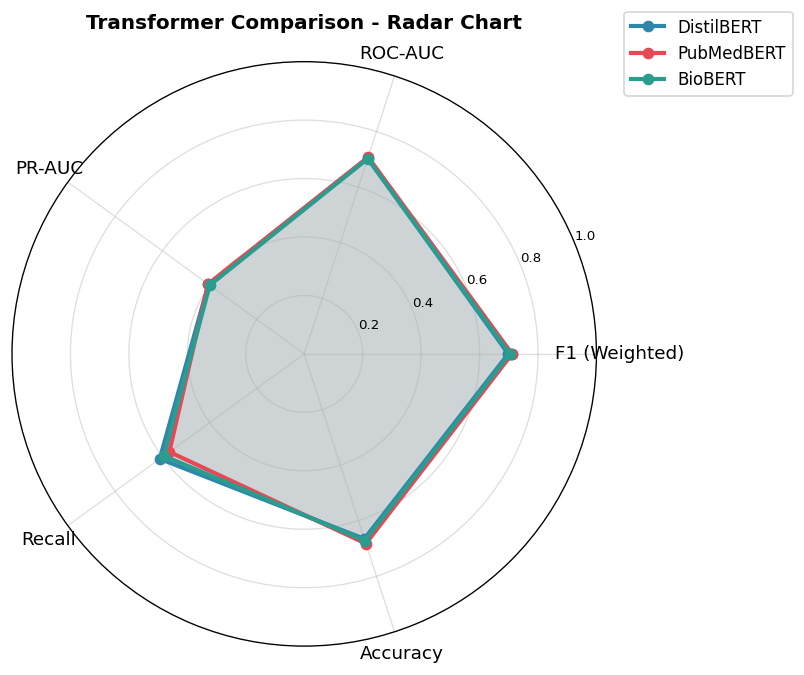

In [9]:
# Metrics and labels for radar chart
metrics_radar = ['F1_Weighted','ROC_AUC','PR_AUC','Recall_Pos','Accuracy']
labels_radar = ['F1 (Weighted)','ROC-AUC','PR-AUC','Recall','Accuracy']

# Transformer models and colors
t_names = ['DistilBERT','PubMedBERT','BioBERT']
t_colors = ['#2E86AB','#E84855','#2A9D8F']

# Angle setup for radar chart
N = len(metrics_radar)

theta = np.linspace(0, 2 * np.pi, N, endpoint=False)
theta = np.concatenate([theta, [theta[0]]])

# Create polar plot
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

# Plot each transformer model
for name, color in zip(t_names, t_colors):
    row = all_results[all_results['Model'] == name].iloc[0]

    vals = [float(row[m]) for m in metrics_radar]
    vals = vals + [vals[0]]

    ax.plot(
        theta, vals,
        'o-', lw=2.5,
        color=color,
        label=name,
        markersize=6
    )

    ax.fill(
        theta, vals,
        alpha=0.12,
        color=color
    )

# Axis formatting
ax.set_xticks(theta[:-1])
ax.set_xticklabels(labels_radar, fontsize=11)

ax.set_ylim(0, 1)

ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8)

ax.set_title(
    'Transformer Comparison - Radar Chart',
    fontweight='bold',
    pad=20,
    fontsize=12
)

ax.legend(
    loc='upper right',
    bbox_to_anchor=(1.35, 1.1),
    fontsize=10
)

ax.grid(True, alpha=0.4)

# Save and display
plt.tight_layout()

plt.savefig(
    f'{EVALUATION_DIR}/eval_05_radar_chart.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Threshold Optimisation and Decision Analysis

This section explores the impact of varying the classification threshold on model performance. Instead of using a fixed threshold of 0.5, different threshold values are evaluated to understand trade-offs between precision, recall, and F1-score.

Predicted probabilities from the best-performing transformer model are used to generate class labels across a range of thresholds. Performance metrics are computed for each threshold, allowing identification of the threshold that maximises F1-score.

In addition to the optimal F1 threshold, a clinically relevant threshold is also considered by enforcing a minimum recall constraint. This reflects scenarios where missing positive cases is more critical than false alarms.

A comparison between default and optimal thresholds is presented to illustrate performance improvements. This analysis highlights the importance of threshold tuning in aligning model predictions with real-world application requirements.

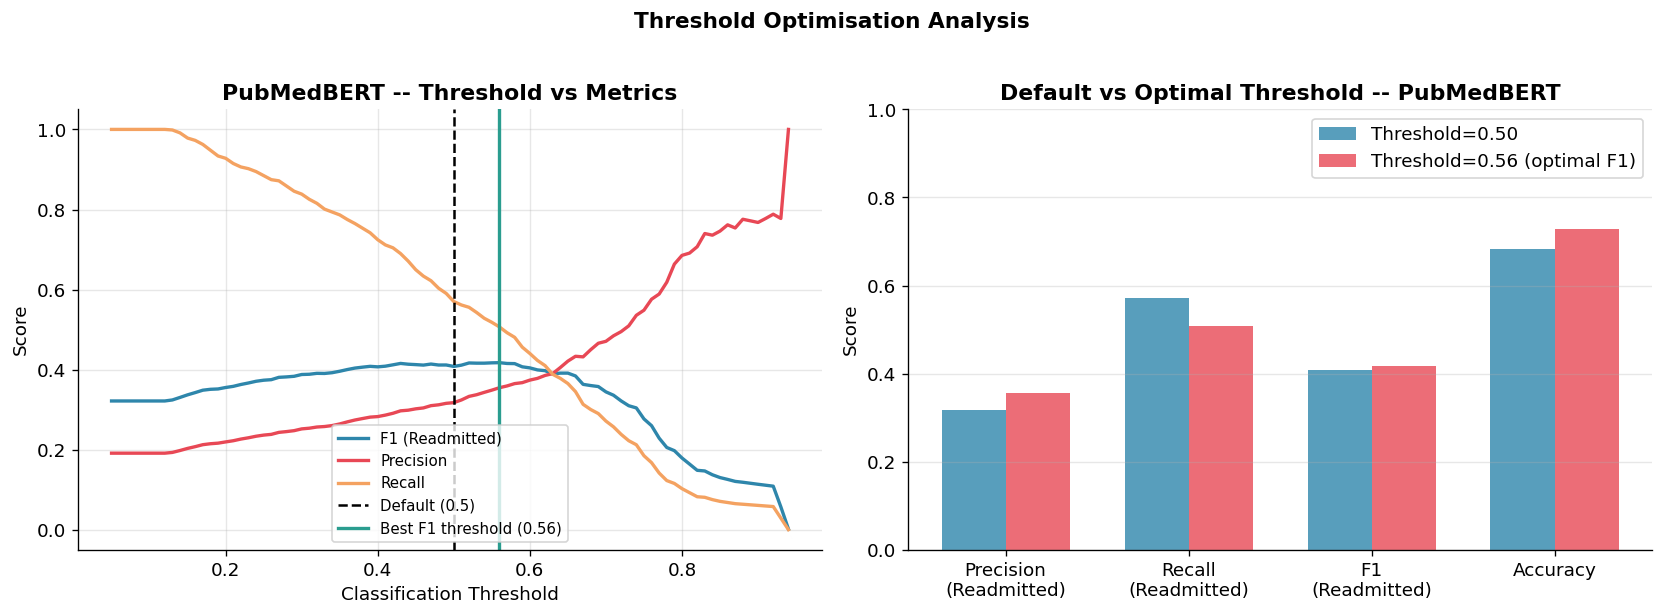

=== Threshold Optimisation -- PubMedBERT ===

  Default threshold (0.50):
    Precision : 0.3183
    Recall    : 0.5706
    F1        : 0.4087

  Optimal F1 threshold (0.56):
    Precision : 0.3556
    Recall    : 0.5072
    F1        : 0.4181

  Clinical threshold (Recall>=0.60): 0.48
    Precision : 0.3129
    Recall    : 0.6037
    F1        : 0.4122


In [10]:
# Best Transformer Model
best_prob = best_t_preds['y_prob']

# Threshold sweep
thresholds = np.arange(0.05, 0.95, 0.01)

f1_scores = []
precisions = []
recalls = []

for t in thresholds:
    preds_t = (best_prob >= t).astype(int)

    rep_t = classification_report(
        y_test, preds_t,
        output_dict=True,
        zero_division=0
    )

    f1_scores.append(rep_t['1']['f1-score'])
    precisions.append(rep_t['1']['precision'])
    recalls.append(rep_t['1']['recall'])


# Convert to arrays
f1_scores = np.array(f1_scores)
precisions = np.array(precisions)
recalls = np.array(recalls)

# Best F1 threshold
best_f1_idx = np.argmax(f1_scores)
best_f1_t = thresholds[best_f1_idx]

# Best threshold for Recall >= 0.60
recall_mask = recalls >= 0.60

if recall_mask.any():
    best_rec_idx = np.argmax(precisions * recall_mask)
    best_rec_t = thresholds[best_rec_idx]
else:
    best_rec_t = None

# Plot setup
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot threshold vs metrics
axes[0].plot(thresholds, f1_scores,  color=PALETTE[0], lw=2, label='F1 (Readmitted)')
axes[0].plot(thresholds, precisions, color=PALETTE[1], lw=2, label='Precision')
axes[0].plot(thresholds, recalls,    color=PALETTE[2], lw=2, label='Recall')

axes[0].axvline(0.5, color='k', linestyle='--', lw=1.5, label='Default (0.5)')
axes[0].axvline(best_f1_t, color=PALETTE[3], linestyle='-', lw=2,
                label=f'Best F1 threshold ({best_f1_t:.2f})')

axes[0].set_title(f'{best_t} -- Threshold vs Metrics', fontweight='bold')
axes[0].set_xlabel('Classification Threshold')
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Default vs optimal comparison
default_pred = (best_prob >= 0.50).astype(int)
optimal_pred = (best_prob >= best_f1_t).astype(int)

default_rep = classification_report(y_test, default_pred, output_dict=True, zero_division=0)
optimal_rep = classification_report(y_test, optimal_pred, output_dict=True, zero_division=0)

# Prepare comparison values
categories = [
    'Precision\n(Readmitted)',
    'Recall\n(Readmitted)',
    'F1\n(Readmitted)',
    'Accuracy'
]

default_vals = [
    default_rep['1']['precision'],
    default_rep['1']['recall'],
    default_rep['1']['f1-score'],
    default_rep['accuracy'],
]

optimal_vals = [
    optimal_rep['1']['precision'],
    optimal_rep['1']['recall'],
    optimal_rep['1']['f1-score'],
    optimal_rep['accuracy'],
]

# Bar plot comparison
x = np.arange(len(categories))
w = 0.35

axes[1].bar(
    x - w/2, default_vals, w,
    label='Threshold=0.50',
    color=PALETTE[0],
    alpha=0.8
)

axes[1].bar(
    x + w/2, optimal_vals, w,
    label=f'Threshold={best_f1_t:.2f} (optimal F1)',
    color=PALETTE[1],
    alpha=0.8
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)

axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel('Score')

axes[1].set_title(
    f'Default vs Optimal Threshold -- {best_t}',
    fontweight='bold'
)

axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

# Save and display
plt.suptitle(
    'Threshold Optimisation Analysis',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    f'{EVALUATION_DIR}/eval_06_threshold_optimisation.png',
    dpi=150, bbox_inches='tight'
)

plt.show()

# Summary output
print(f'=== Threshold Optimisation -- {best_t} ===')

print('\n  Default threshold (0.50):')
print(f'    Precision : {default_rep["1"]["precision"]:.4f}')
print(f'    Recall    : {default_rep["1"]["recall"]:.4f}')
print(f'    F1        : {default_rep["1"]["f1-score"]:.4f}')

print(f'\n  Optimal F1 threshold ({best_f1_t:.2f}):')
print(f'    Precision : {optimal_rep["1"]["precision"]:.4f}')
print(f'    Recall    : {optimal_rep["1"]["recall"]:.4f}')
print(f'    F1        : {optimal_rep["1"]["f1-score"]:.4f}')

if best_rec_t:
    print(f'\n  Clinical threshold (Recall>=0.60): {best_rec_t:.2f}')

    clinical_pred = (best_prob >= best_rec_t).astype(int)
    clin_rep = classification_report(
        y_test,
        clinical_pred,
        output_dict=True,
        zero_division=0
    )

    print(f'    Precision : {clin_rep["1"]["precision"]:.4f}')
    print(f'    Recall    : {clin_rep["1"]["recall"]:.4f}')
    print(f'    F1        : {clin_rep["1"]["f1-score"]:.4f}')


## Calibration and Reliability Analysis

This section evaluates the calibration of model predictions, assessing how well predicted probabilities reflect true outcome likelihoods. Calibration is particularly important in clinical settings where probability estimates are used for decision-making.

Reliability diagrams are used to compare predicted probabilities with observed outcomes across bins. A well-calibrated model should closely follow the diagonal line, indicating that predicted probabilities align with actual event frequencies.

The Brier score is also computed for each model to provide a quantitative measure of calibration quality. Lower Brier scores indicate better alignment between predicted probabilities and true labels.

By comparing calibration performance across models, this analysis highlights differences in prediction reliability and identifies models that provide more trustworthy probability estimates.

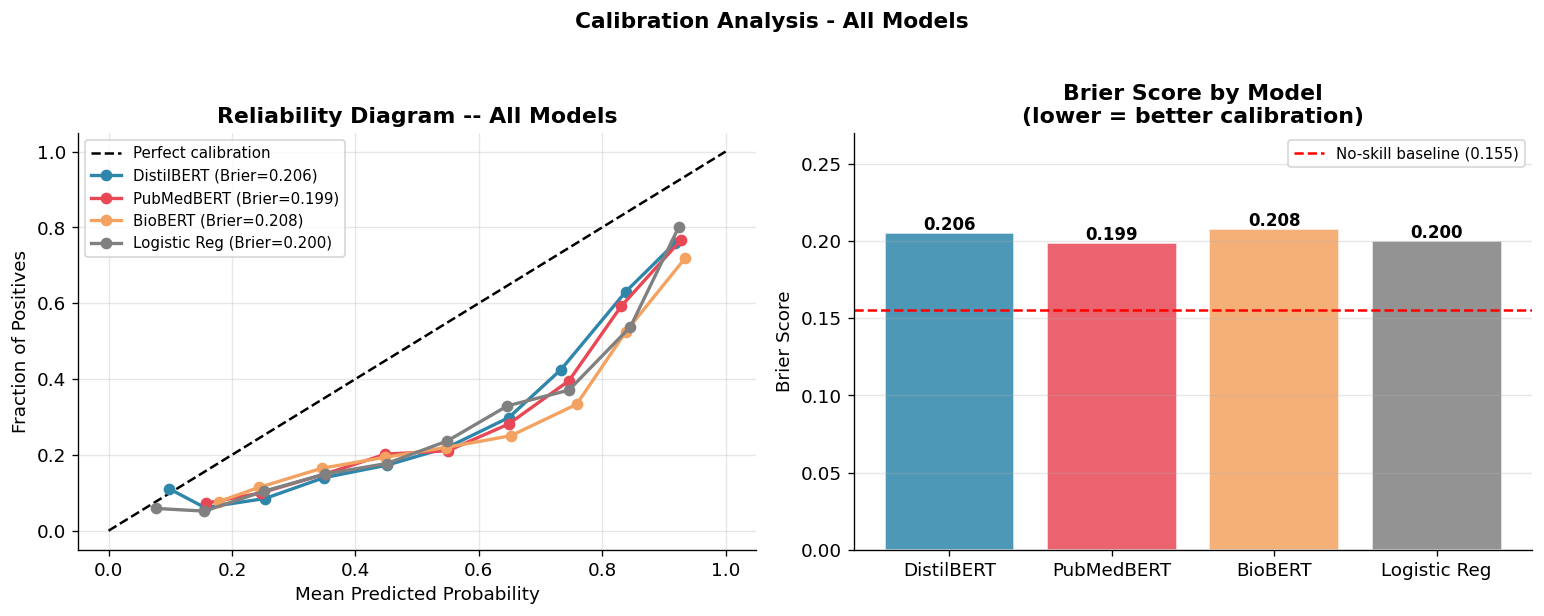

=== Calibration - Brier Scores (lower = better) ===
  DistilBERT           : 0.2056
  PubMedBERT           : 0.1989
  BioBERT              : 0.2079
  Logistic Reg         : 0.2004
  No-skill baseline    : 0.1553

  -> Brier score < 0.155 means the model adds value over naive prediction.


In [11]:
# Create figure
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Model probabilities
model_probs = [
    ('DistilBERT', db_preds['y_prob'], PALETTE[0]),
    ('PubMedBERT', pm_preds['y_prob'], PALETTE[1]),
    ('BioBERT', bb_preds['y_prob'], PALETTE[2]),
    ('Logistic Reg', bl_preds['y_prob'], 'grey'),
]

# Reliability diagram
axes[0].plot([0,1],[0,1], 'k--', lw=1.5, label='Perfect calibration')

for name, probs, color in model_probs:
    fraction_pos, mean_pred = calibration_curve(
        y_test, probs,
        n_bins=10,
        strategy='uniform'
    )

    brier = brier_score_loss(y_test, probs)

    axes[0].plot(
        mean_pred, fraction_pos,
        'o-',
        color=color,
        lw=2,
        markersize=6,
        label=f'{name} (Brier={brier:.3f})'
    )

axes[0].set_title('Reliability Diagram -- All Models', fontweight='bold')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)


# Brier score bar chart
names = [m[0] for m in model_probs]
briers = [brier_score_loss(y_test, m[1]) for m in model_probs]
colors = [m[2] for m in model_probs]

bars = axes[1].bar(
    names,
    briers,
    color=colors,
    edgecolor='white',
    alpha=0.85
)

for bar, val in zip(bars, briers):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        f'{val:.3f}',
        ha='center',
        fontweight='bold',
        fontsize=10
    )

# No-skill baseline
baseline_brier = brier_score_loss(
    y_test,
    np.full_like(y_test, y_test.mean(), dtype=float)
)

axes[1].axhline(
    baseline_brier,
    color='red',
    linestyle='--',
    lw=1.5,
    label=f'No-skill baseline ({baseline_brier:.3f})'
)

axes[1].set_title(
    'Brier Score by Model\n(lower = better calibration)',
    fontweight='bold'
)

axes[1].set_ylabel('Brier Score')
axes[1].set_ylim(0, max(briers) * 1.3)
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='y', alpha=0.3)

# Save and display
plt.suptitle(
    'Calibration Analysis - All Models',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    f'{EVALUATION_DIR}/eval_07_calibration.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Summary output
print('=== Calibration - Brier Scores (lower = better) ===')

for name, probs, _ in model_probs:
    bs = brier_score_loss(y_test, probs)
    print(f'  {name:<20} : {bs:.4f}')

print(f'  {"No-skill baseline":<20} : {baseline_brier:.4f}')

print(f'\n  -> Brier score < {baseline_brier:.3f} means the model adds value over naive prediction.')

## Final Evaluation Summary and Model Selection

This section provides a consolidated summary of performance across all evaluated models, highlighting key metrics for final comparison. The summary focuses on weighted F1-score, ROC-AUC, PR-AUC, and recall for the positive class.

A structured table is presented to enable direct comparison between baseline and transformer models. This allows identification of performance trends and differences across modelling approaches.

The best-performing model is selected based on ROC-AUC, representing overall discriminative ability. In addition, the strongest baseline model is identified to establish a reference point for comparison.

The performance uplift between the best transformer model and the best baseline is computed, quantifying the improvement achieved through advanced modelling techniques. This summary supports the final conclusion and model selection for the study.

In [12]:
# Print summary header
print('=' * 70)
print('  FINAL EVALUATION SUMMARY')
print('=' * 70)

# Columns for summary
cols_summary = [
    'Model','Type',
    'F1_Weighted','ROC_AUC','PR_AUC','Recall_Pos'
]

summary_table = all_results[cols_summary].to_string(
    index=False,
    float_format='{:.4f}'.format
)

print(summary_table)

# Identify best models
best_all = all_results.loc[all_results['ROC_AUC'].idxmax()]

baseline_df = all_results[all_results['Type'] == 'Baseline']
best_bl = baseline_df.loc[baseline_df['ROC_AUC'].idxmax()]

# Print best model comparison
print(f'\n  Best overall    : {best_all["Model"]}  (ROC-AUC={best_all["ROC_AUC"]:.4f})')
print(f'  Best baseline   : {best_bl["Model"]}  (ROC-AUC={best_bl["ROC_AUC"]:.4f})')

uplift = best_all['ROC_AUC'] - best_bl['ROC_AUC']

print(f'  Uplift          : +{uplift:.4f} ROC-AUC')

print('=' * 70)

  FINAL EVALUATION SUMMARY
              Model        Type  F1_Weighted  ROC_AUC  PR_AUC  Recall_Pos
Logistic Regression    Baseline       0.7199   0.7021  0.3882      0.5605
      Random Forest    Baseline       0.7208   0.6776  0.3744      0.4640
         Linear SVM    Baseline       0.7344   0.6912  0.3666      0.0317
         DistilBERT Transformer       0.6983   0.7041  0.4051      0.6110
         PubMedBERT Transformer       0.7111   0.7080  0.4066      0.5706
            BioBERT Transformer       0.7034   0.7025  0.3996      0.5937

  Best overall    : PubMedBERT  (ROC-AUC=0.7080)
  Best baseline   : Logistic Regression  (ROC-AUC=0.7021)
  Uplift          : +0.0059 ROC-AUC
